# Detection Frequency vs Annual NOx Emissions — Grid Analysis (US + Global)

8×8 uniform-log-grid 2D histograms of (annual positive detection rate, annual NOx emissions)
for power plants, after interference-zone filtering.

**Paper revision (2026-04-28): all paths point to the 100 m wind versions.**
- US: `pipeline_100m_run/Run_100m_20260414/...augmented_localtz.csv` (LST-fixed)
- World: `pipeline_test_labelling_100m/Run_100m_20260428/...` (100 m re-labelling)
- Output: `results/paper_figures/NOx_Detection_vs_Emissions_LogGrid_Filtered.{pdf,png}`


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize
from sklearn.neighbors import BallTree
from haversine import haversine, Unit
from math import radians, log10
from tqdm import tqdm

# Set publication-quality defaults
plt.rcdefaults()
plt.rcParams['font.family'] = 'Nimbus Roman'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# =========================
# Constants
# =========================
EARTH_RADIUS_KM = 6371.0
PLANT_RADIUS_BASE_KM = 20.0
PLANT_MAX_SEARCH_KM = 150.0
CITY_POP_THRESHOLD = 200000
CITY_RADIUS_SCALE = 9.0
CITY_RADIUS_BASE_KM = 10.0
CITY_RADIUS_MAX_KM = 90.0
US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

# Grid settings
N_BINS_X = 8  # detection frequency
N_BINS_Y = 8  # emissions

# =========================
# Paths (paper revision, 100 m wind everywhere)
# =========================
US_HOURLY_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
US_FACILITY_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
US_ANNUAL_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv'

WORLD_EMIT_CSV    = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/valid_tropomi_emissions_with_qa.csv'
WORLD_LOC_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'
WORLD_CITIES_CSV  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'

OUTPUT_DIR        = '/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
# =========================
# Helper functions
# =========================
def _process_source_dataframe(df_raw, lat_col, lon_col, id_col=None, value_col=None):
    if df_raw is None or df_raw.empty:
        return None, None
    df = df_raw.copy()
    std_lat, std_lon, std_id, std_value = 'latitude', 'longitude', 'ID', 'value'
    col_map = {lat_col: std_lat, lon_col: std_lon}
    if id_col: col_map[id_col] = std_id
    if value_col: col_map[value_col] = std_value
    df = df[list(col_map.keys())].rename(columns=col_map)
    for c in [std_lat, std_lon, std_value]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df.dropna(subset=[std_lat, std_lon], inplace=True)
    if df.empty:
        return df, None
    df['lat_rad'] = np.radians(df[std_lat])
    df['lon_rad'] = np.radians(df[std_lon])
    tree = BallTree(df[['lat_rad', 'lon_rad']].values, metric='haversine')
    return df, tree

def identify_us_interference_one_year(plants_year_df, cities_df):
    source_plants_df, plant_tree = _process_source_dataframe(
        plants_year_df, 'Latitude', 'Longitude',
        id_col='Facility ID', value_col='NOx Mass (short tons)')
    source_cities_df, city_tree = _process_source_dataframe(
        cities_df, 'latitude', 'longitude',
        id_col='name', value_col='population')

    plant_interfered_ids, city_interfered_ids = set(), set()
    if plants_year_df.empty:
        return plant_interfered_ids, city_interfered_ids

    for _, tgt in plants_year_df.iterrows():
        tid = tgt['Facility ID']
        tlat = tgt['Latitude']; tlon = tgt['Longitude']
        temis = tgt.get('NOx Mass (short tons)', 0)
        if pd.isna(tlat) or pd.isna(tlon) or pd.isna(temis):
            continue
        target_coords_rad = np.array([[radians(tlat), radians(tlon)]])

        if plant_tree is not None:
            nearby_idx = plant_tree.query_radius(target_coords_rad, r=(PLANT_MAX_SEARCH_KM / EARTH_RADIUS_KM))[0]
            for idx in nearby_idx:
                src = source_plants_df.iloc[idx]
                if src['ID'] == tid:
                    continue
                src_emis = src.get('value', 0)
                if pd.isna(src_emis) or src_emis < temis:
                    continue
                dist_km = haversine((tlat, tlon), (src['latitude'], src['longitude']), unit=Unit.KILOMETERS)
                if dist_km < PLANT_RADIUS_BASE_KM:
                    plant_interfered_ids.add(tid)
                    break

        if city_tree is not None:
            nearby_idx = city_tree.query_radius(target_coords_rad, r=(CITY_RADIUS_MAX_KM / EARTH_RADIUS_KM))[0]
            for idx in nearby_idx:
                c = source_cities_df.iloc[idx]
                pop = c.get('value', 0)
                if pd.isna(pop) or pop < CITY_POP_THRESHOLD:
                    continue
                radius = CITY_RADIUS_BASE_KM + (log10(max(1, pop)) * CITY_RADIUS_SCALE)
                interference_radius_km = min(radius, CITY_RADIUS_MAX_KM)
                dist_km = haversine((tlat, tlon), (c['latitude'], c['longitude']), unit=Unit.KILOMETERS)
                if dist_km < interference_radius_km:
                    city_interfered_ids.add(tid)
                    break

    return plant_interfered_ids, city_interfered_ids

def identify_plants_in_interference_zones_global(plants_df, cities_df):
    df_plants = plants_df.copy()
    if 'nox_emis_ty' in df_plants.columns:
        df_plants['annual_nox_emission'] = df_plants['nox_emis_ty']
    else:
        df_plants['annual_nox_emission'] = -df_plants.index

    df_plants['lat_rad'] = np.radians(df_plants['latitude'])
    df_plants['lon_rad'] = np.radians(df_plants['longitude'])
    plant_tree = BallTree(df_plants[['lat_rad', 'lon_rad']].values, metric='haversine')

    cities_filtered = cities_df[cities_df['population'] >= CITY_POP_THRESHOLD].copy()
    if not cities_filtered.empty:
        cities_filtered['lat_rad'] = np.radians(cities_filtered['latitude'])
        cities_filtered['lon_rad'] = np.radians(cities_filtered['longitude'])
        city_tree = BallTree(cities_filtered[['lat_rad', 'lon_rad']].values, metric='haversine')
    else:
        city_tree = None

    interfered_plants = set()
    for idx, tgt in tqdm(df_plants.iterrows(), total=len(df_plants), desc="Checking global interference"):
        tid = tgt['ID']; tlat = tgt['latitude']; tlon = tgt['longitude']
        temis = tgt.get('annual_nox_emission', 0)
        if pd.isna(tlat) or pd.isna(tlon):
            continue
        tgt_rad = np.array([[radians(tlat), radians(tlon)]])

        near_idx = plant_tree.query_radius(tgt_rad, r=(PLANT_MAX_SEARCH_KM / EARTH_RADIUS_KM))[0]
        for j in near_idx:
            if j == idx: continue
            src = df_plants.iloc[j]
            semis = src.get('annual_nox_emission', 0)
            if pd.notna(semis) and semis > temis:
                d = haversine((tlat, tlon), (src['latitude'], src['longitude']), unit=Unit.KILOMETERS)
                if d < PLANT_RADIUS_BASE_KM:
                    interfered_plants.add(tid)
                    break

        if city_tree and tid not in interfered_plants:
            near_idx = city_tree.query_radius(tgt_rad, r=(CITY_RADIUS_MAX_KM / EARTH_RADIUS_KM))[0]
            for k in near_idx:
                city = cities_filtered.iloc[k]
                pop = city['population']
                radius = CITY_RADIUS_BASE_KM + (log10(max(1, pop)) * CITY_RADIUS_SCALE)
                rr = min(radius, CITY_RADIUS_MAX_KM)
                d = haversine((tlat, tlon), (city['latitude'], city['longitude']), unit=Unit.KILOMETERS)
                if d < rr:
                    interfered_plants.add(tid)
                    break

    return interfered_plants


In [3]:
# =========================
# Load data
# =========================
print("Loading datasets...")

cities_df = pd.read_csv(WORLD_CITIES_CSV)

us_filtered_df = pd.read_csv(US_HOURLY_CSV, low_memory=False)
us_locations_all = pd.read_csv(US_FACILITY_CSV)
us_annual = pd.read_csv(US_ANNUAL_CSV)

global_filtered_df = pd.read_csv(WORLD_EMIT_CSV, low_memory=False)
global_locations = pd.read_csv(WORLD_LOC_CSV)

# =========================
# Process US data with proper filtering
# =========================
print("Processing US data with interference zone filtering...")

if 'NOx_Rank' in us_locations_all.columns:
    us_locations_all = us_locations_all.sort_values('NOx_Rank', ascending=True)
us_locations_top500 = us_locations_all.head(500).copy()
top500_ids = set(us_locations_top500['Facility_ID'])

us_annual_top500 = us_annual[us_annual['Facility ID'].isin(top500_ids)].copy()

present_counts = (us_annual_top500[us_annual_top500['Year'].isin(US_YEARS)]
                  .groupby('Facility ID')['Year'].nunique())
complete_6y_ids = set(present_counts[present_counts == len(US_YEARS)].index)

print(f"US plants in all 6 years: {len(complete_6y_ids)}")

us_annual_top500 = us_annual_top500.dropna(subset=['Latitude', 'Longitude'])

all_year_interfered = set()
print("\n================ US Year-by-Year Interference ================")
for yr in US_YEARS:
    df_y = us_annual_top500[(us_annual_top500['Year'] == yr) &
                            (us_annual_top500['Facility ID'].isin(complete_6y_ids))].copy()
    if df_y.empty:
        continue
    plant_set, city_set = identify_us_interference_one_year(df_y, cities_df)
    union_set = set(map(str, plant_set.union(city_set)))
    all_year_interfered |= union_set
    print(f"[{yr}] Plants interfered by plants: {len(plant_set)}; by cities: {len(city_set)}; unique union: {len(union_set)}")

complete_6y_ids_str = set(map(str, complete_6y_ids))
kept_us_ids = complete_6y_ids_str - all_year_interfered

print(f"US plants removed due to interference in any year: {len(all_year_interfered & complete_6y_ids_str)}")
print(f"US plants for analysis (6y & non-interfered): {len(kept_us_ids)}")

us_avg_emissions = (us_annual_top500[(us_annual_top500['Year'].isin(US_YEARS)) &
                                     (us_annual_top500['Facility ID'].astype(str).isin(kept_us_ids))]
                    .groupby('Facility ID')['NOx Mass (short tons)']
                    .mean()
                    .reset_index()
                    .rename(columns={'NOx Mass (short tons)': 'avg_nox_short_tons'}))
us_avg_emissions['avg_nox_tons'] = us_avg_emissions['avg_nox_short_tons'] * 0.907185

us_grouped = us_filtered_df[us_filtered_df['location'].astype(str).isin(kept_us_ids)].groupby("location")["plume_label"]
us_positive = us_grouped.sum()
us_positive_counts = us_positive.reset_index(name='positive_detections')
us_positive_counts['annual_positive_rate'] = us_positive_counts['positive_detections'] / 6

us_plot_data = pd.merge(us_avg_emissions, us_positive_counts,
                        left_on='Facility ID', right_on='location', how='inner')


Loading datasets...
Processing US data with interference zone filtering...
US plants in all 6 years: 460

================ US Year-by-Year Interference ================
[2019] Plants interfered by plants: 91; by cities: 252; unique union: 283
[2020] Plants interfered by plants: 92; by cities: 252; unique union: 283
[2021] Plants interfered by plants: 92; by cities: 252; unique union: 283
[2022] Plants interfered by plants: 92; by cities: 252; unique union: 283
[2023] Plants interfered by plants: 92; by cities: 252; unique union: 283
[2024] Plants interfered by plants: 92; by cities: 252; unique union: 283
US plants removed due to interference in any year: 289
US plants for analysis (6y & non-interfered): 171


In [4]:
# =========================
# Process Global data with proper filtering
# =========================
print("\nProcessing Global data with interference zone filtering...")

if 'nox_emis_ty' in global_locations.columns:
    global_subset = global_locations.sort_values('nox_emis_ty', ascending=False).head(6000).copy()
else:
    global_subset = global_locations.head(6000).copy()

global_interfered = identify_plants_in_interference_zones_global(global_subset, cities_df)
keep_ids_glb = set(map(str, global_subset['ID'])) - set(map(str, global_interfered))

print(f"Global plants removed due to interference: {len(global_interfered)}")
print(f"Global plants for analysis: {len(keep_ids_glb)}")

global_subset_clean = global_subset[global_subset['ID'].astype(str).isin(keep_ids_glb)].copy()

global_grouped = global_filtered_df[global_filtered_df['location'].astype(str).isin(keep_ids_glb)].groupby("location")["plume_label"]
global_positive = global_grouped.sum()
global_positive_counts = global_positive.reset_index(name='positive_detections')

global_plot_data = pd.merge(global_subset_clean[['ID', 'nox_emis_ty']], global_positive_counts,
                            left_on='ID', right_on='location', how='inner')
global_plot_data = global_plot_data.rename(columns={'nox_emis_ty': 'avg_nox_tons'})

# Remove invalid data points
us_plot_data = us_plot_data[(us_plot_data['avg_nox_tons'] > 0) & (us_plot_data['positive_detections'] > 0)]
global_plot_data = global_plot_data[(global_plot_data['avg_nox_tons'] > 0) & (global_plot_data['positive_detections'] > 0)]



Processing Global data with interference zone filtering...


Checking global interference:   0%|          | 0/6000 [00:00<?, ?it/s]

Checking global interference: 100%|██████████| 6000/6000 [00:07<00:00, 779.70it/s] 


Global plants removed due to interference: 4935
Global plants for analysis: 1065


In [5]:
# =========================
# Emissions Preservation Statistics
# =========================
us_complete_6y_emissions = (us_annual_top500[(us_annual_top500['Year'].isin(US_YEARS)) &
                                             (us_annual_top500['Facility ID'].isin(complete_6y_ids))]
                            .groupby('Facility ID')['NOx Mass (short tons)']
                            .mean()
                            .sum() * 0.907185)
us_kept_emissions = us_avg_emissions['avg_nox_tons'].sum()
us_emissions_preserved_pct = (us_kept_emissions / us_complete_6y_emissions * 100) if us_complete_6y_emissions > 0 else 0

global_initial_emissions = global_subset['nox_emis_ty'].sum()
global_kept_emissions = global_subset_clean['nox_emis_ty'].sum()
global_emissions_preserved_pct = (global_kept_emissions / global_initial_emissions * 100) if global_initial_emissions > 0 else 0

print("\n" + "="*60)
print("EMISSIONS PRESERVATION AFTER INTERFERENCE ZONE FILTERING")
print("="*60)
print("\nUnited States:")
print(f"  Plants before filtering: {len(complete_6y_ids)}")
print(f"  Plants after filtering: {len(kept_us_ids)}")
print(f"  Plant retention rate: {len(kept_us_ids)/len(complete_6y_ids)*100:.1f}%")
print(f"  Total emissions before filtering: {us_complete_6y_emissions:,.0f} tons/year")
print(f"  Total emissions after filtering: {us_kept_emissions:,.0f} tons/year")
print(f"  EMISSIONS PRESERVED: {us_emissions_preserved_pct:.1f}%")
print(f"  Emissions lost: {us_complete_6y_emissions - us_kept_emissions:,.0f} tons/year ({100-us_emissions_preserved_pct:.1f}%)")

print("\nGlobal:")
print(f"  Plants before filtering: {len(global_subset)}")
print(f"  Plants after filtering: {len(global_subset_clean)}")
print(f"  Plant retention rate: {len(global_subset_clean)/len(global_subset)*100:.1f}%")
print(f"  Total emissions before filtering: {global_initial_emissions:,.0f} tons/year")
print(f"  Total emissions after filtering: {global_kept_emissions:,.0f} tons/year")
print(f"  EMISSIONS PRESERVED: {global_emissions_preserved_pct:.1f}%")
print(f"  Emissions lost: {global_initial_emissions - global_kept_emissions:,.0f} tons/year ({100-global_emissions_preserved_pct:.1f}%)")

us_avg_before = us_complete_6y_emissions / len(complete_6y_ids) if len(complete_6y_ids) > 0 else 0
us_avg_after = us_kept_emissions / len(kept_us_ids) if len(kept_us_ids) > 0 else 0
global_avg_before = global_initial_emissions / len(global_subset) if len(global_subset) > 0 else 0
global_avg_after = global_kept_emissions / len(global_subset_clean) if len(global_subset_clean) > 0 else 0

print("\nAverage Emissions per Plant:")
print(f"  US before filtering: {us_avg_before:,.0f} tons/year/plant")
print(f"  US after filtering: {us_avg_after:,.0f} tons/year/plant")
print(f"  Global before filtering: {global_avg_before:,.0f} tons/year/plant")
print(f"  Global after filtering: {global_avg_after:,.0f} tons/year/plant")



EMISSIONS PRESERVATION AFTER INTERFERENCE ZONE FILTERING

United States:
  Plants before filtering: 460
  Plants after filtering: 171
  Plant retention rate: 37.2%
  Total emissions before filtering: 617,822 tons/year
  Total emissions after filtering: 303,436 tons/year
  EMISSIONS PRESERVED: 49.1%
  Emissions lost: 314,385 tons/year (50.9%)

Global:
  Plants before filtering: 6000
  Plants after filtering: 1065
  Plant retention rate: 17.8%
  Total emissions before filtering: 9,904,359 tons/year
  Total emissions after filtering: 2,090,788 tons/year
  EMISSIONS PRESERVED: 21.1%
  Emissions lost: 7,813,571 tons/year (78.9%)

Average Emissions per Plant:
  US before filtering: 1,343 tons/year/plant
  US after filtering: 1,774 tons/year/plant
  Global before filtering: 1,651 tons/year/plant
  Global after filtering: 1,963 tons/year/plant



GRID STATISTICS (8x8 Uniform Log Grid)

US Grid:
  Total plants: 171
  X-axis (emissions) range: 133.7 to 14005.8 tons/year
  Y-axis (detection)  range: 10.05 to 283.25 observations/year
  Max plants per cell: 11
  Non-empty cells: 39 out of 64
  Grid coverage: 60.9%

Global Grid:
  Total plants: 1064
  X-axis (emissions) range: 197.3 to 32616.8 tons/year
  Y-axis (detection)  range: 0.9 to 276.1 observations
  Max plants per cell: 105
  Non-empty cells: 45 out of 64
  Grid coverage: 70.3%

✓ Figures saved to:
  /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/NOx_Detection_vs_Emissions_LogGrid_Filtered.pdf
  /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/NOx_Detection_vs_Emissions_LogGrid_Filtered.png


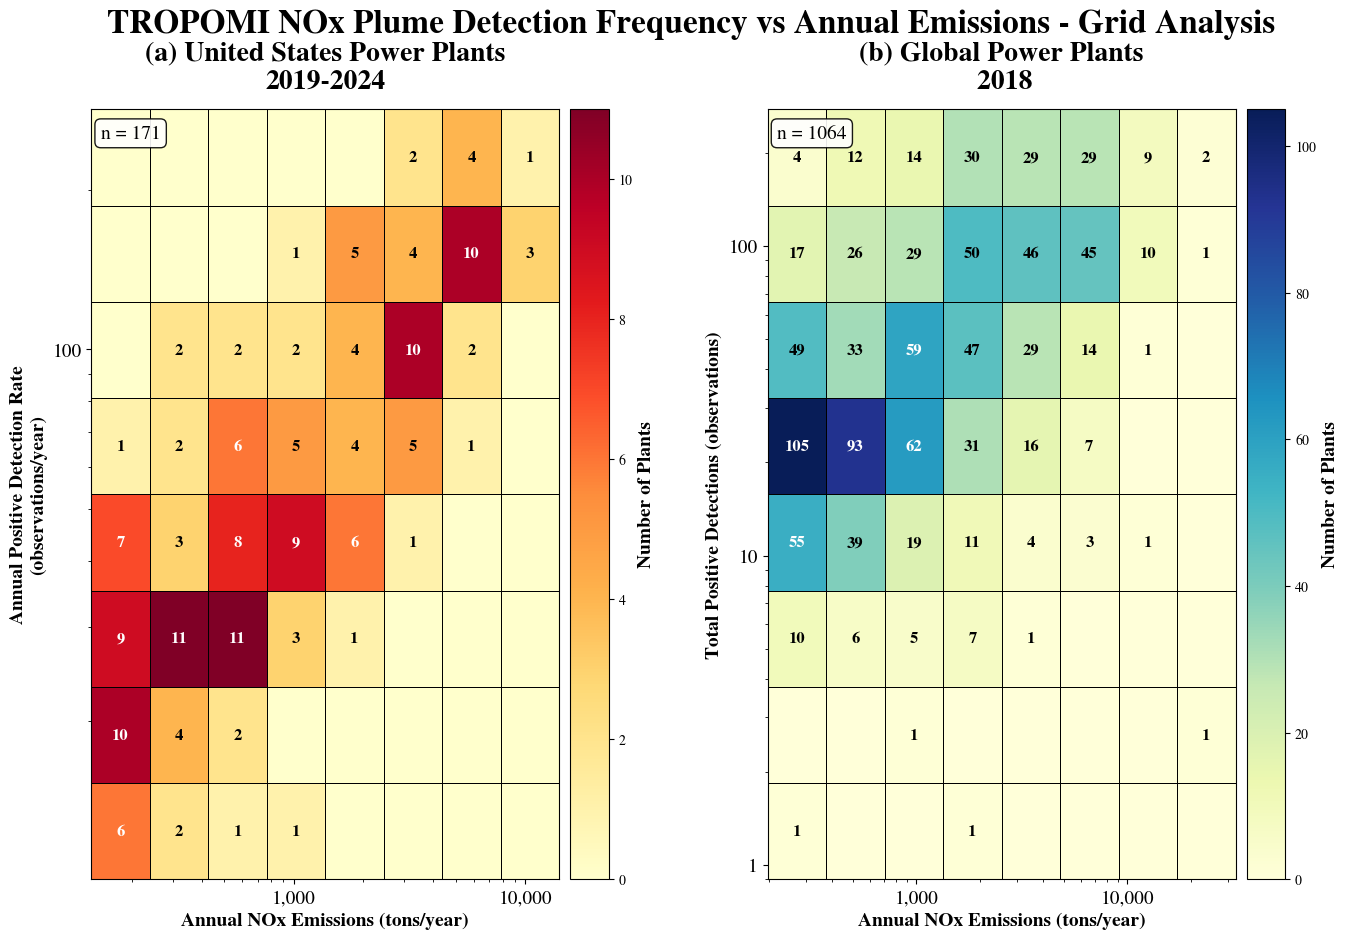

In [7]:
# =========================
# Uniform Log Grid Plot — emissions on X (cause), detections on Y (effect)
# (axes swapped per reviewer feedback 2026-04)
# =========================
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 2, figure=fig, wspace=0.2, hspace=0.5)

def add_grid_labels(ax, H, xedges, yedges, fontsize=12, thresh=0):
    """Add count labels to each grid cell (H[i,j] -> bin (xedges[i], yedges[j]))."""
    for i in range(len(xedges) - 1):
        for j in range(len(yedges) - 1):
            count = int(H[i, j])
            if count > thresh:
                x_center = 10**((np.log10(xedges[i]) + np.log10(xedges[i + 1])) / 2)
                y_center = 10**((np.log10(yedges[j]) + np.log10(yedges[j + 1])) / 2)
                ax.text(x_center, y_center, str(count),
                       ha='center', va='center', fontsize=fontsize,
                       fontweight='bold', color='white' if count > H.max()/2 else 'black')

# US Grid Plot — X: emissions, Y: detection rate
ax1 = fig.add_subplot(gs[0, 0])

us_x_min = us_plot_data['avg_nox_tons'].min() * 0.9
us_x_max = us_plot_data['avg_nox_tons'].max() * 1.1
us_x_bins = np.logspace(np.log10(us_x_min), np.log10(us_x_max), N_BINS_X + 1)

us_y_min = max(0.1, us_plot_data['annual_positive_rate'].min() * 0.9)
us_y_max = us_plot_data['annual_positive_rate'].max() * 1.1
us_y_bins = np.logspace(np.log10(us_y_min), np.log10(us_y_max), N_BINS_Y + 1)

H_us, xedges_us, yedges_us = np.histogram2d(
    us_plot_data['avg_nox_tons'], us_plot_data['annual_positive_rate'],
    bins=[us_x_bins, us_y_bins])

X_us, Y_us = np.meshgrid(xedges_us, yedges_us)
pcm1 = ax1.pcolormesh(X_us, Y_us, H_us.T, cmap='YlOrRd',
                      edgecolors='black', linewidths=0.5,
                      norm=Normalize(vmin=0, vmax=H_us.max()))

add_grid_labels(ax1, H_us, xedges_us, yedges_us)

ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Annual NOx Emissions (tons/year)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Annual Positive Detection Rate\n(observations/year)', fontsize=14, fontweight='bold')
ax1.set_title('(a) United States Power Plants\n2019-2024', fontsize=20, fontweight='bold', pad=15)

ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:.1f}' if x < 10 else f'{int(x)}'))

ax1.grid(False)

ax1.text(0.02, 0.98, f'n = {len(us_plot_data)}',
        transform=ax1.transAxes, fontsize=14, ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

cbar1 = plt.colorbar(pcm1, ax=ax1, pad=0.02)
cbar1.set_label('Number of Plants', fontsize=14, fontweight='bold')
cbar1.ax.tick_params(labelsize=10)

# Global Grid Plot — X: emissions, Y: total positive detections
ax2 = fig.add_subplot(gs[0, 1])

global_x_min = global_plot_data['avg_nox_tons'].min() * 0.9
global_x_max = global_plot_data['avg_nox_tons'].max() * 1.1
global_x_bins = np.logspace(np.log10(global_x_min), np.log10(global_x_max), N_BINS_X + 1)

global_y_min = max(0.1, global_plot_data['positive_detections'].min() * 0.9)
global_y_max = global_plot_data['positive_detections'].max() * 1.1
global_y_bins = np.logspace(np.log10(global_y_min), np.log10(global_y_max), N_BINS_Y + 1)

H_global, xedges_global, yedges_global = np.histogram2d(
    global_plot_data['avg_nox_tons'], global_plot_data['positive_detections'],
    bins=[global_x_bins, global_y_bins])

X_global, Y_global = np.meshgrid(xedges_global, yedges_global)
pcm2 = ax2.pcolormesh(X_global, Y_global, H_global.T, cmap='YlGnBu',
                      edgecolors='black', linewidths=0.5,
                      norm=Normalize(vmin=0, vmax=H_global.max()))

add_grid_labels(ax2, H_global, xedges_global, yedges_global)

ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Annual NOx Emissions (tons/year)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Positive Detections (observations)', fontsize=14, fontweight='bold')
ax2.set_title('(b) Global Power Plants\n 2018', fontsize=20, fontweight='bold', pad=15)

ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:.0f}' if x < 10 else f'{int(x)}'))

ax2.grid(False)

ax2.text(0.02, 0.98, f'n = {len(global_plot_data)}',
        transform=ax2.transAxes, fontsize=14, ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

cbar2 = plt.colorbar(pcm2, ax=ax2, pad=0.02)
cbar2.set_label('Number of Plants', fontsize=14, fontweight='bold')
cbar2.ax.tick_params(labelsize=10)

fig.suptitle('TROPOMI NOx Plume Detection Frequency vs Annual Emissions - Grid Analysis',
            fontsize=24, fontweight='bold', y=0.98)

# Print detailed grid statistics
print("\n" + "="*60)
print("GRID STATISTICS (8x8 Uniform Log Grid)")
print("="*60)

print(f"\nUS Grid:")
print(f"  Total plants: {len(us_plot_data)}")
print(f"  X-axis (emissions) range: {us_x_min:.1f} to {us_x_max:.1f} tons/year")
print(f"  Y-axis (detection)  range: {us_y_min:.2f} to {us_y_max:.2f} observations/year")
print(f"  Max plants per cell: {int(H_us.max())}")
print(f"  Non-empty cells: {np.sum(H_us > 0)} out of {N_BINS_X * N_BINS_Y}")
print(f"  Grid coverage: {100 * np.sum(H_us > 0) / (N_BINS_X * N_BINS_Y):.1f}%")

print(f"\nGlobal Grid:")
print(f"  Total plants: {len(global_plot_data)}")
print(f"  X-axis (emissions) range: {global_x_min:.1f} to {global_x_max:.1f} tons/year")
print(f"  Y-axis (detection)  range: {global_y_min:.1f} to {global_y_max:.1f} observations")
print(f"  Max plants per cell: {int(H_global.max())}")
print(f"  Non-empty cells: {np.sum(H_global > 0)} out of {N_BINS_X * N_BINS_Y}")
print(f"  Grid coverage: {100 * np.sum(H_global > 0) / (N_BINS_X * N_BINS_Y):.1f}%")

# Save figure
output_path = os.path.join(OUTPUT_DIR, 'NOx_Detection_vs_Emissions_LogGrid_Filtered.pdf')
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(output_path.replace('.pdf', '.png'), dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✓ Figures saved to:")
print(f"  {output_path}")
print(f"  {output_path.replace('.pdf', '.png')}")
print("="*60)

plt.show()